# Implementation of Particle Filter for Adaptive Cruise Control Systems

Implementation based on Wang et al. (2020): *Online parameter estimation methods for adaptive cruise control systems*

## Setup & Initialization

In [ ]:
# Import necessary dependencies
import numpy as np 
import matplotlib.pyplot as plt 
import os 

# Import driving scenarios with vehicle profiles
from scenarios import scenario_1_non_eq, scenario_1_eq, scenario_2_data, scenario_3_data, scenario_4_data

# Import estimators with particle filter estimator and plot functions
from utilities import (
    particle_filter,
    plot_parameter_pdfs,
    plot_convergence_with_uncertainty,
    compare_rls_pf
)

# Create plots directory
pf_plots_dir = os.path.join(os.pardir, "plots/pf_plots") 

if not os.path.exists(pf_plots_dir):
    os.makedirs(pf_plots_dir)
    print(f"Created directory: {pf_plots_dir}")
else:
    print(f"Using existing directory: {pf_plots_dir}")

Created directory: ../plots/pf_plots


## Initialization of Synthetic Data

In [70]:
np.random.seed(43) # seed for reproducibility

s_0 = 37.8 # initial space gap (meters)
u_0 = 33.0 # initial lead velocity (m/s)
v_0 = 32.5 # initial following velocity (m/s)

dt = 0.1 # time step (10 Hz, as in the paper)

time = 900 # number of time steps
t_axis = np.arange(time)

true_theta = np.array([0.08, 0.12, 1.5]) # true theta values from paper

dv_max = 3.0 # maximum acceleration/deceleration (m/s^2)

print("===========================================")
print("Initialized Model Parameters")
print(f"Time steps: {time}, dt: {dt}")
print(f"Initial conditions: u_0 = {u_0}, v_0 = {v_0}, s_0 = {s_0}")
print(f"Theta vector initialized: alpha = {true_theta[0]}, beta = {true_theta[1]}, tau = {true_theta[2]}")
print(f"Total t_axis steps created: {len(t_axis)}")
print("===========================================")

Initialized Model Parameters
Time steps: 900, dt: 0.1
Initial conditions: u_0 = 33.0, v_0 = 32.5, s_0 = 37.8
Theta vector initialized: alpha = 0.08, beta = 0.12, tau = 1.5
Total t_axis steps created: 900


## Generate Synthetic Data

In [71]:
# SCENARIO 1: Non-equilibrium
print("===========================================")
print("Scenario 1: Random Walk (Non-Equilibrium)")
print("Parameters Initialized:")
print("===========================================")

u_t, v_t, s_t = scenario_1_non_eq(u_0, v_0, s_0, time, dv_max, dt, true_theta)

Scenario 1: Random Walk (Non-Equilibrium)
Parameters Initialized:


### Visualization of the Generated Data

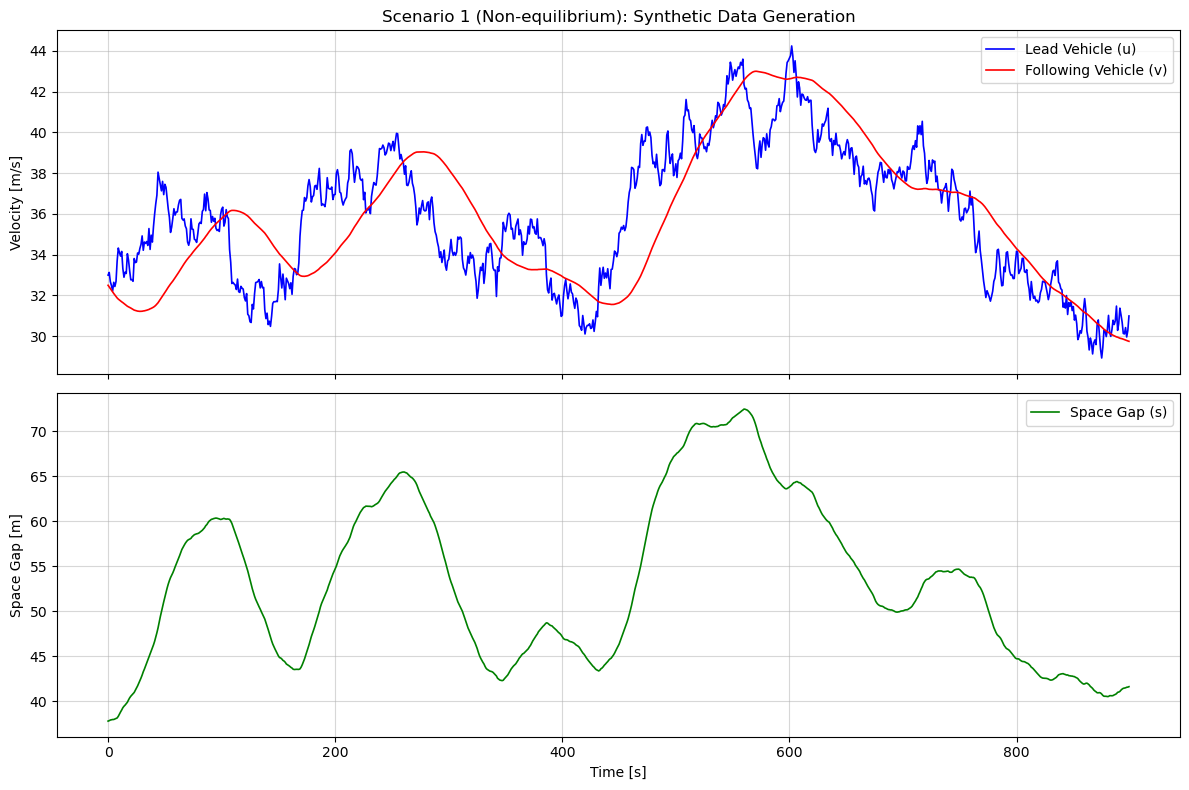

In [76]:
# Plot synthetic data
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

time_axis = np.arange(len(u_t)) # remove 'dt' factor!

# Velocity plot
axes[0].plot(time_axis, u_t, 'b-', label='Lead Vehicle (u)', linewidth=1.2)
axes[0].plot(time_axis, v_t, 'r-', label='Following Vehicle (v)', linewidth=1.2)
axes[0].set_ylabel('Velocity [m/s]')
axes[0].legend()
axes[0].grid(True, alpha=0.5)
axes[0].set_title('Scenario 1 (Non-equilibrium): Synthetic Data Generation')

# Space gap plot
axes[1].plot(time_axis, s_t, 'g-', label='Space Gap (s)', linewidth=1.2)
axes[1].set_ylabel('Space Gap [m]')
axes[1].set_xlabel('Time [s]')
axes[1].legend()
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

## Particle Filter Algorithm

The particle filter estimates the augmented state $\underline{x}^a = [s, v, \alpha, \beta, \tau]^T$ using:

1. **State Propagation**: Propagate particles through CTH-RV dynamics
2. **Weight Update**: Update weights based on measurement likelihood
3. **Resampling**: Resample particles when effective sample size drops

### Particle Filer - Scenario 1 (Non-equilibrium)

In [78]:
# Particle filter for scenario 1 (non-equilibrium)
theta_history, theta_mean_history, theta_std_history, particles_snapshots = particle_filter(
    u_t, v_t, s_t, 
    dt=dt,
    true_theta=true_theta, 
    label="Scenario 1: Non-Equilibrium",
    Np=500  # Number of particles (as in paper)
)


[PARTICLE FILTER - SCENARIO: Scenario 1: Non-Equilibrium]
Number of particles: 500
--------------------------------------------------
Final estimated α = 0.0882 (true=0.0800)
Final estimated β = 0.1976 (true=0.1200)
Final estimated τ = 1.4961 (true=1.5000)
--------------------------------------------------
α Error: 0.0082
β Error: 0.0776
τ Error: 0.0039


### Plot Parameter Convergence with Uncertainty Bands

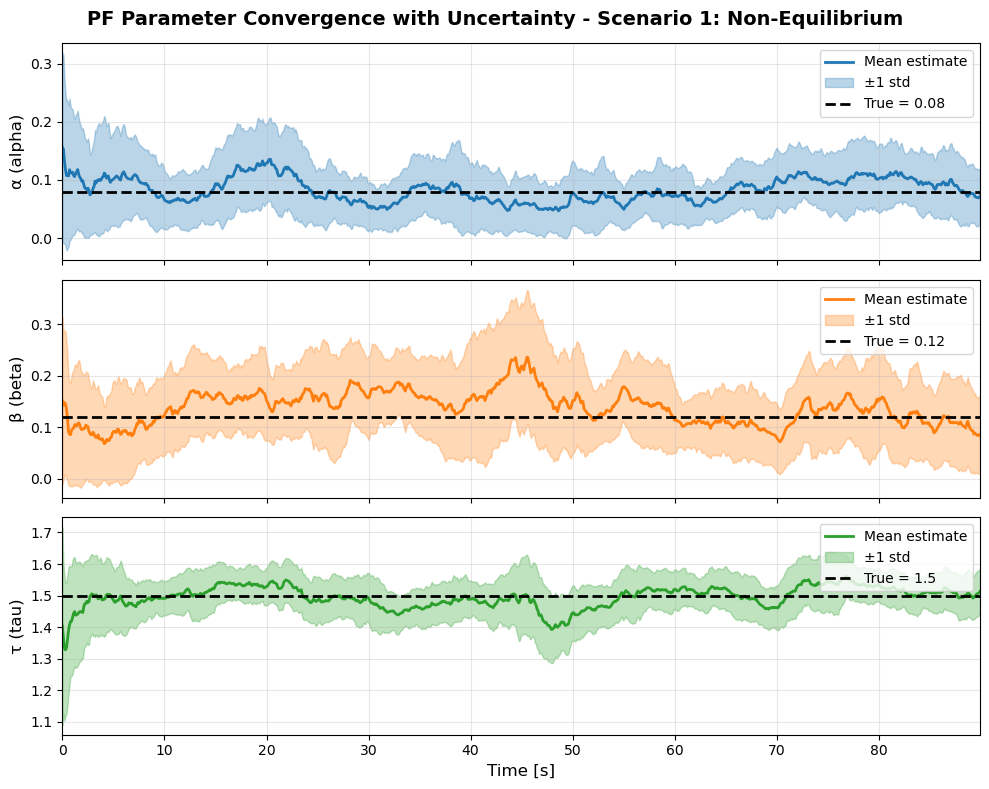

In [57]:
# Plot convergence with uncertainty bands
fig = plot_convergence_with_uncertainty(
    theta_mean_history, 
    theta_std_history, 
    true_theta, 
    dt, 
    "Scenario 1: Non-Equilibrium"
)
plt.show()

### Plot Posterior PDFs at Different Time Steps

This replicates Figure 2/3 from the Wang et al. (2020) paper.

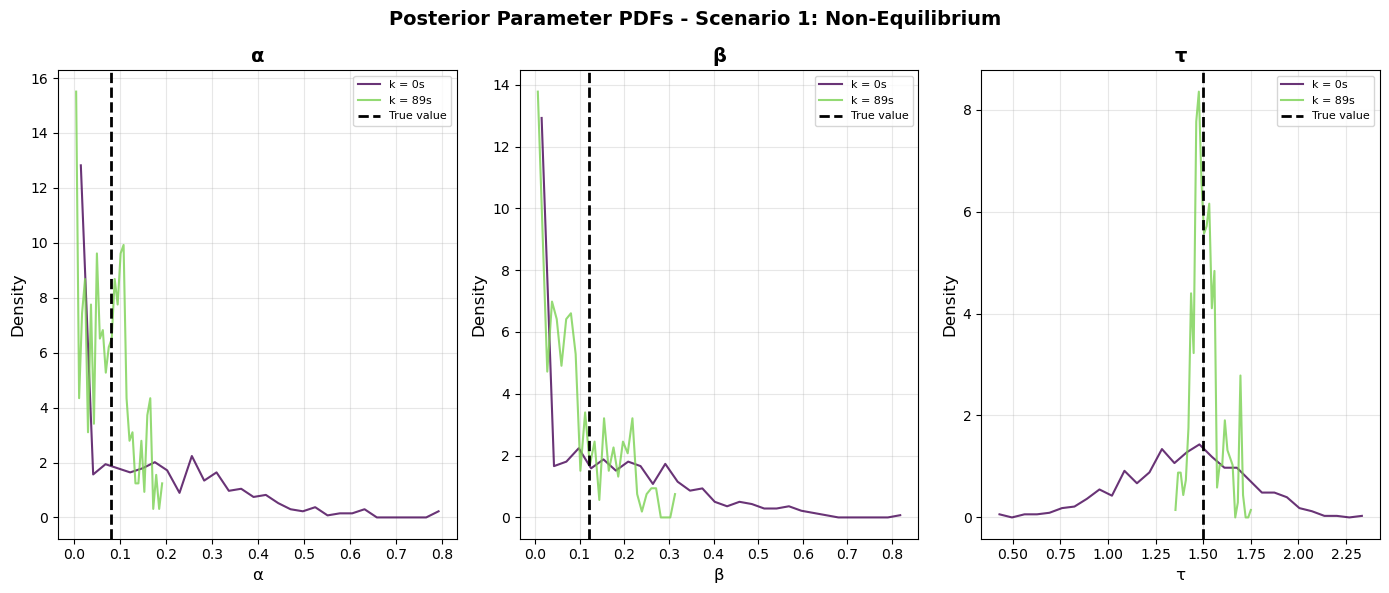

In [58]:
# Plot posterior PDFs
fig = plot_parameter_pdfs(
    particles_snapshots, 
    true_theta, 
    dt, 
    "Scenario 1: Non-Equilibrium"
)
plt.show()

## Compare RLS vs Particle Filter


Running RLS...

[SCENARIO: Scenario 1: Non-Equilibrium]
Final estimated alpha = 0.080 (true=0.080)
Final estimated beta  = 0.120 (true=0.120)
Final estimated tau   = 1.500 (true=1.500)
-------------------------
Alpha Error: 0.000
Beta  Error: -0.000
Tau   Error: 0.000
[SCENARIO: Scenario 1: Non-Equilibrium] cond(X^T X) = 2.28e+03

Running Particle Filter...

[PARTICLE FILTER - SCENARIO: Scenario 1: Non-Equilibrium]
Number of particles: 500
--------------------------------------------------
Final estimated α = 0.0669 (true=0.0800)
Final estimated β = 0.0703 (true=0.1200)
Final estimated τ = 1.4914 (true=1.5000)
--------------------------------------------------
α Error: 0.0131
β Error: 0.0497
τ Error: 0.0086


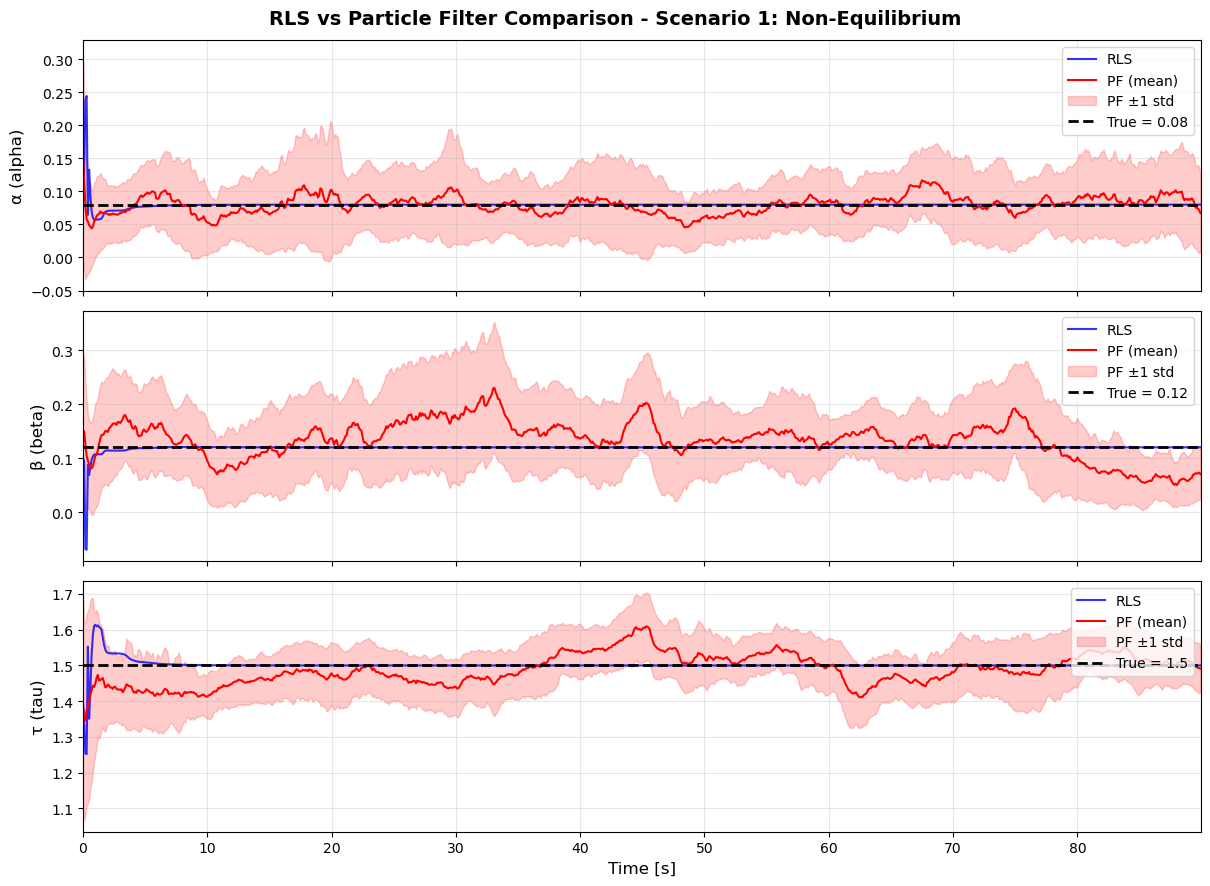

In [59]:
# Run both methods and compare
fig, theta_rls, theta_pf, particles = compare_rls_pf(
    u_t, v_t, s_t, 
    dt=dt, 
    true_theta=true_theta, 
    label="Scenario 1: Non-Equilibrium",
    Np=500
)
plt.show()

## Scenario 1: Equilibrium Case

This demonstrates the **identifiability problem** discussed in Section III-C of the paper. At equilibrium ($u = v$), the parameters $\alpha$ and $\beta$ are not identifiable.

In [60]:
# Generate equilibrium data
print("===========================================")
print("Scenario 1: Random Walk (Equilibrium)")
print("===========================================")
u_t_eq, v_t_eq, s_t_eq = scenario_1_eq(u_0, v_0, s_0, time, dv_max, dt, true_theta)

Scenario 1: Random Walk (Equilibrium)



Running RLS...

[SCENARIO: Scenario 1: Equilibrium]
Final estimated alpha = 0.080 (true=0.080)
Final estimated beta  = 0.120 (true=0.120)
Final estimated tau   = 1.500 (true=1.500)
-------------------------
Alpha Error: -0.000
Beta  Error: 0.000
Tau   Error: 0.000
[SCENARIO: Scenario 1: Equilibrium] cond(X^T X) = 2.03e+05

Running Particle Filter...

[PARTICLE FILTER - SCENARIO: Scenario 1: Equilibrium]
Number of particles: 500
--------------------------------------------------
Final estimated α = 0.1111 (true=0.0800)
Final estimated β = 0.8106 (true=0.1200)
Final estimated τ = 1.5558 (true=1.5000)
--------------------------------------------------
α Error: 0.0311
β Error: 0.6906
τ Error: 0.0558


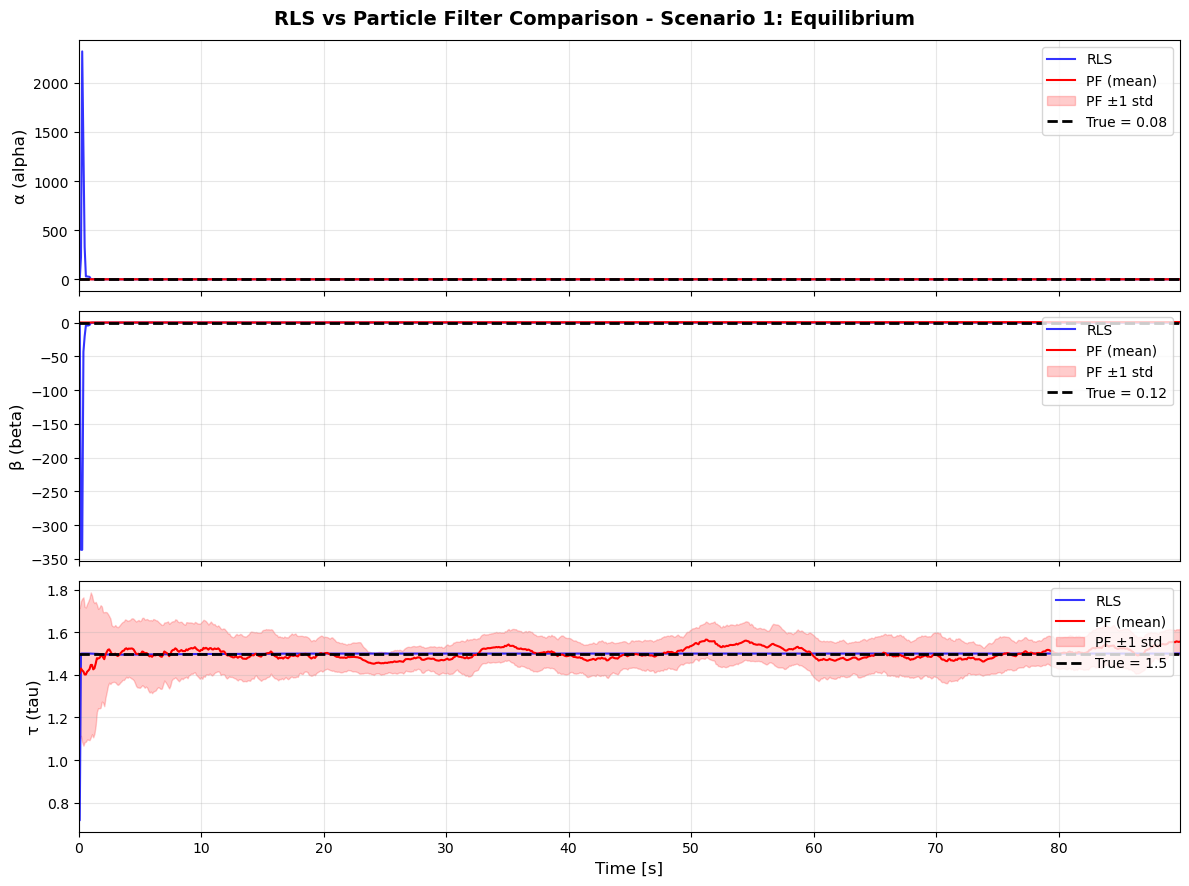

In [61]:
# Compare methods on equilibrium data
fig_eq, theta_rls_eq, theta_pf_eq, particles_eq = compare_rls_pf(
    u_t_eq, v_t_eq, s_t_eq, 
    dt=dt, 
    true_theta=true_theta, 
    label="Scenario 1: Equilibrium",
    Np=500
)
plt.show()

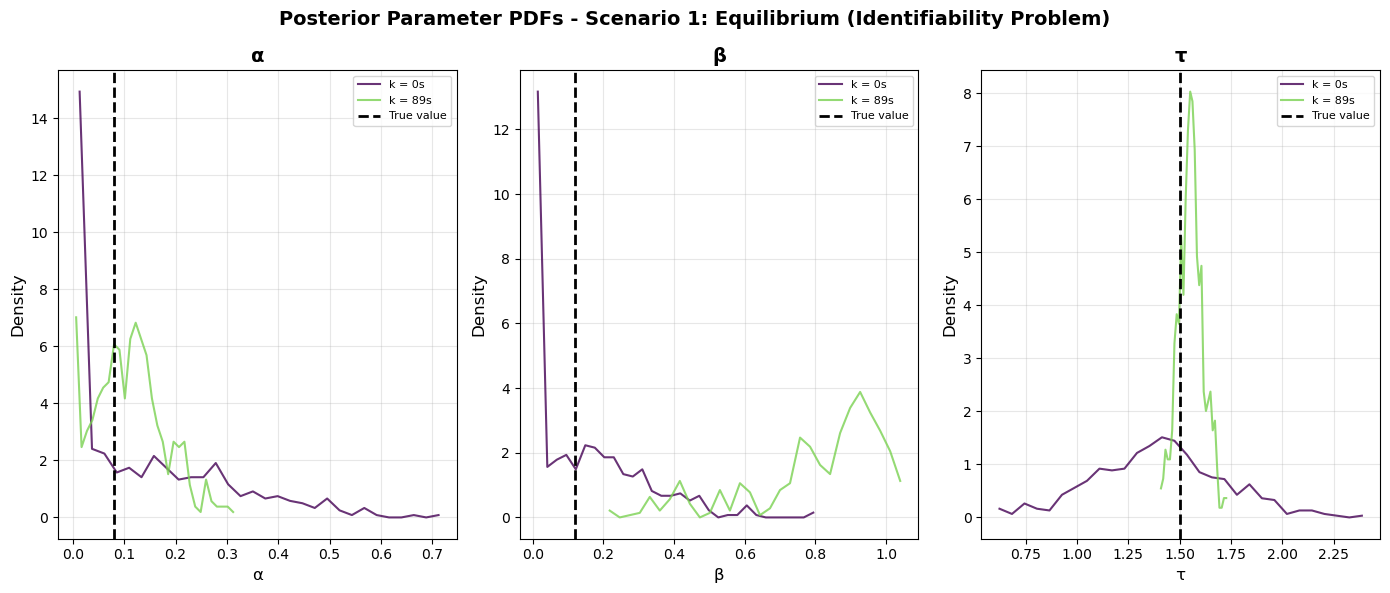

In [62]:
# Plot PDFs for equilibrium case - shows parameter drift
fig = plot_parameter_pdfs(
    particles_eq, 
    true_theta, 
    dt, 
    "Scenario 1: Equilibrium (Identifiability Problem)"
)
plt.show()

## Other Scenarios

### Scenario 2: Curved Road


Running RLS...

[SCENARIO: Scenario 2: Curved Road]
Final estimated alpha = 0.080 (true=0.080)
Final estimated beta  = 0.120 (true=0.120)
Final estimated tau   = 1.500 (true=1.500)
-------------------------
Alpha Error: 0.000
Beta  Error: -0.000
Tau   Error: 0.000
[SCENARIO: Scenario 2: Curved Road] cond(X^T X) = 6.83e+03

Running Particle Filter...

[PARTICLE FILTER - SCENARIO: Scenario 2: Curved Road]
Number of particles: 500
--------------------------------------------------
Final estimated α = 0.1047 (true=0.0800)
Final estimated β = 0.2481 (true=0.1200)
Final estimated τ = 1.4846 (true=1.5000)
--------------------------------------------------
α Error: 0.0247
β Error: 0.1281
τ Error: 0.0154


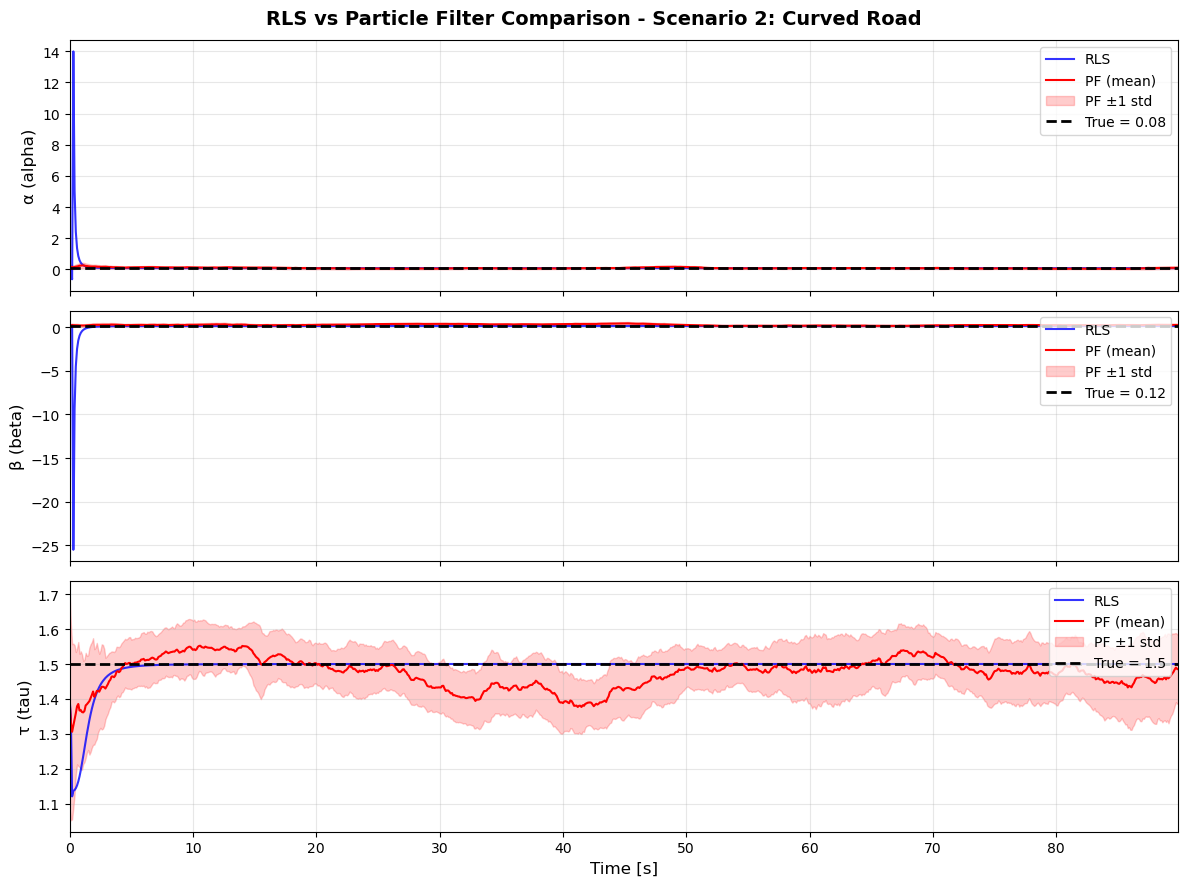

In [63]:
u_t_2, v_t_2, s_t_2 = scenario_2_data(u_0, v_0, s_0, time, dv_max, dt, true_theta)

fig_2, theta_rls_2, theta_pf_2, particles_2 = compare_rls_pf(
    u_t_2, v_t_2, s_t_2, 
    dt=dt, 
    true_theta=true_theta, 
    label="Scenario 2: Curved Road",
    Np=500
)
plt.show()

### Scenario 3: Suburban Environment


Running RLS...

[SCENARIO: Scenario 3: Suburban]
Final estimated alpha = 0.109 (true=0.080)
Final estimated beta  = -27.194 (true=0.120)
Final estimated tau   = 3.262 (true=1.500)
-------------------------
Alpha Error: -0.029
Beta  Error: 27.314
Tau   Error: -1.762
[SCENARIO: Scenario 3: Suburban] cond(X^T X) = 3.98e+05

Running Particle Filter...

[PARTICLE FILTER - SCENARIO: Scenario 3: Suburban]
Number of particles: 500
--------------------------------------------------
Final estimated α = 0.1349 (true=0.0800)
Final estimated β = 0.1218 (true=0.1200)
Final estimated τ = 2.4282 (true=1.5000)
--------------------------------------------------
α Error: 0.0549
β Error: 0.0018
τ Error: 0.9282


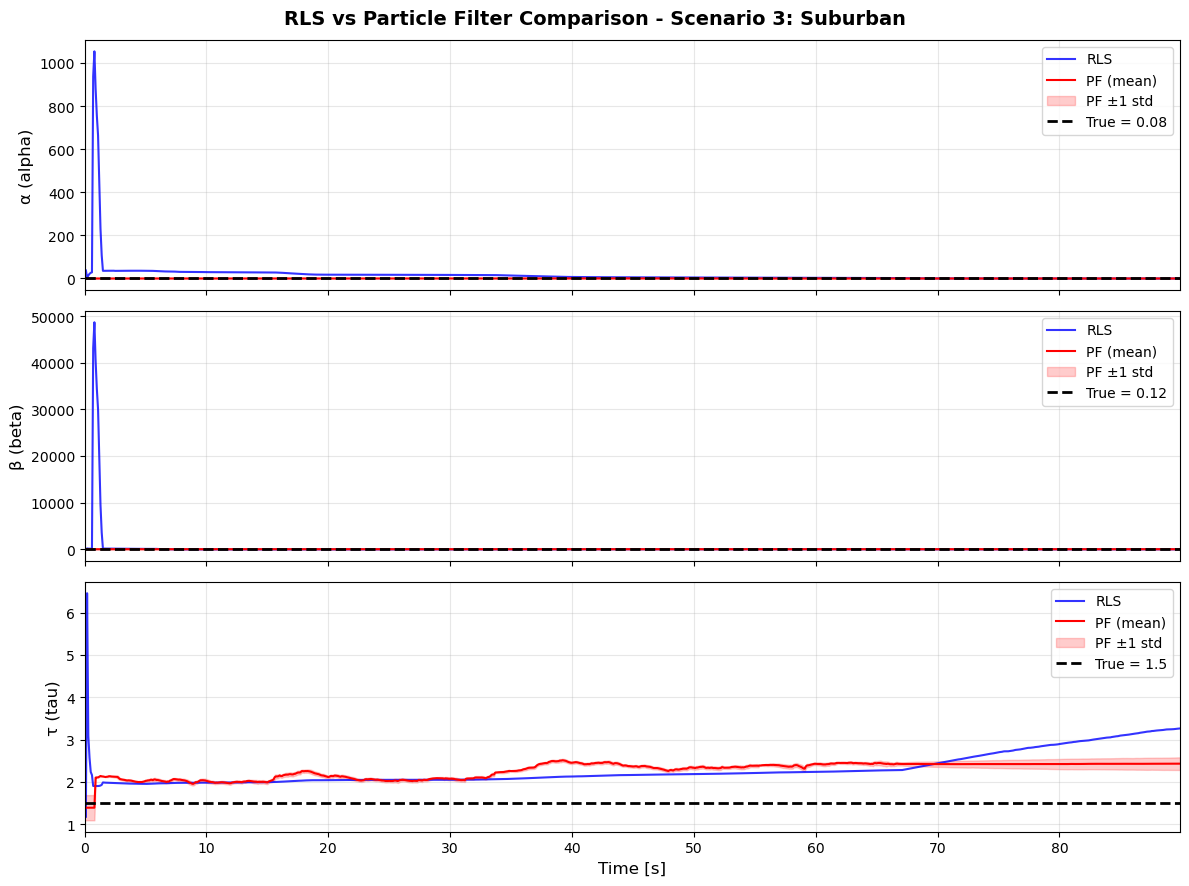

In [64]:
u_t_3, v_t_3, s_t_3 = scenario_3_data(u_0, v_0, s_0, time, dv_max, dt, true_theta)

fig_3, theta_rls_3, theta_pf_3, particles_3 = compare_rls_pf(
    u_t_3, v_t_3, s_t_3, 
    dt=dt, 
    true_theta=true_theta, 
    label="Scenario 3: Suburban",
    Np=500
)
plt.show()

### Scenario 4: Aggressive Driver


Running RLS...

[SCENARIO: Scenario 4: Aggressive Driver]
Final estimated alpha = 0.080 (true=0.080)
Final estimated beta  = 0.120 (true=0.120)
Final estimated tau   = 1.500 (true=1.500)
-------------------------
Alpha Error: 0.000
Beta  Error: -0.000
Tau   Error: 0.000
[SCENARIO: Scenario 4: Aggressive Driver] cond(X^T X) = 5.89e+03

Running Particle Filter...

[PARTICLE FILTER - SCENARIO: Scenario 4: Aggressive Driver]
Number of particles: 500
--------------------------------------------------
Final estimated α = 0.0460 (true=0.0800)
Final estimated β = 0.2699 (true=0.1200)
Final estimated τ = 1.4974 (true=1.5000)
--------------------------------------------------
α Error: 0.0340
β Error: 0.1499
τ Error: 0.0026


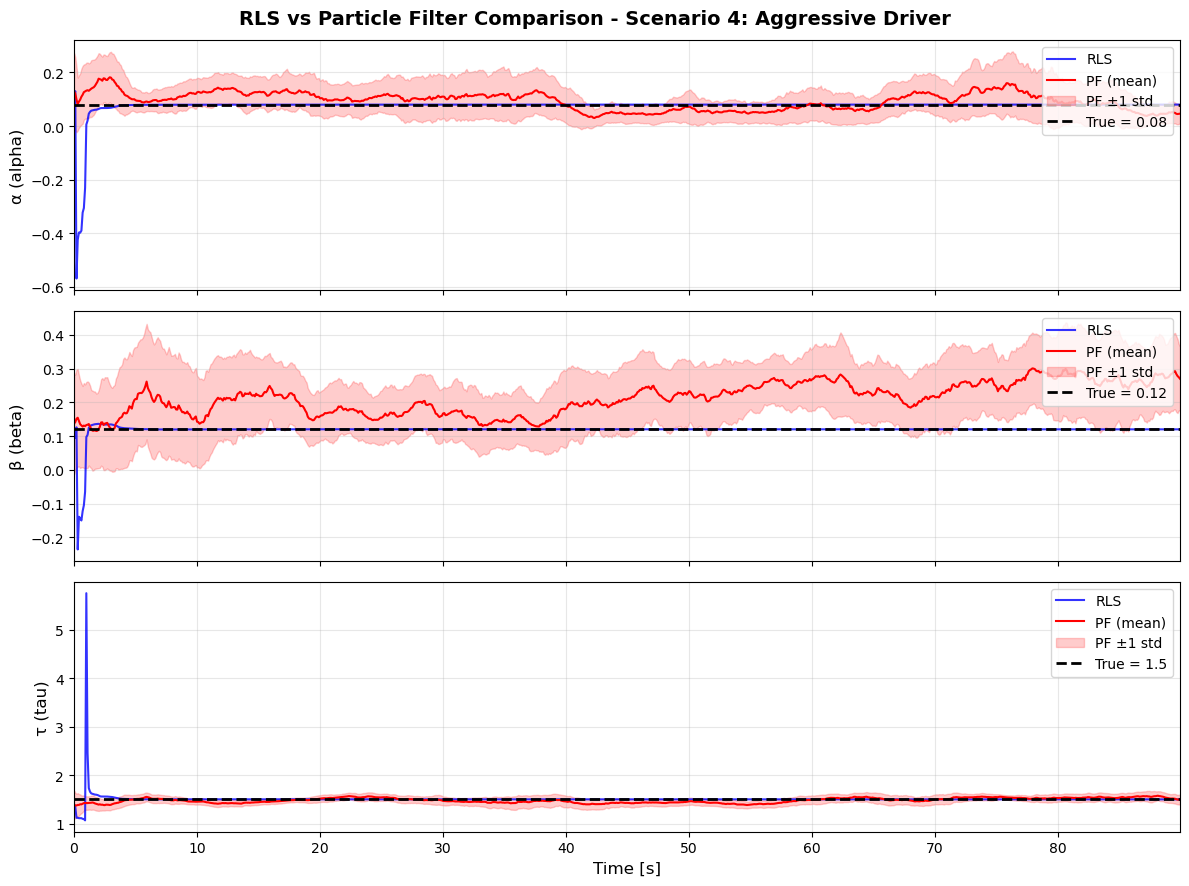

In [65]:
u_t_4, v_t_4, s_t_4 = scenario_4_data(u_0, v_0, s_0, time, dv_max, dt, true_theta)

fig_4, theta_rls_4, theta_pf_4, particles_4 = compare_rls_pf(
    u_t_4, v_t_4, s_t_4, 
    dt=dt, 
    true_theta=true_theta, 
    label="Scenario 4: Aggressive Driver",
    Np=500
)
plt.show()

## Summary Table

In [66]:
print("\n" + "="*70)
print("SUMMARY: FINAL PARAMETER ESTIMATES")
print("="*70)
print(f"{'Scenario':<25} {'Method':<8} {'α':<10} {'β':<10} {'τ':<10}")
print("-"*70)
print(f"{'True Values':<25} {'':<8} {true_theta[0]:<10.4f} {true_theta[1]:<10.4f} {true_theta[2]:<10.4f}")
print("-"*70)

scenarios = [
    ("1: Non-Equilibrium", theta_rls, theta_pf),
    ("1: Equilibrium", theta_rls_eq, theta_pf_eq),
    ("2: Curved Road", theta_rls_2, theta_pf_2),
    ("3: Suburban", theta_rls_3, theta_pf_3),
    ("4: Aggressive", theta_rls_4, theta_pf_4),
]

for name, rls, pf in scenarios:
    print(f"{name:<25} {'RLS':<8} {rls[-1,0]:<10.4f} {rls[-1,1]:<10.4f} {rls[-1,2]:<10.4f}")
    print(f"{'':<25} {'PF':<8} {pf[-1,0]:<10.4f} {pf[-1,1]:<10.4f} {pf[-1,2]:<10.4f}")
    print("-"*70)


SUMMARY: FINAL PARAMETER ESTIMATES
Scenario                  Method   α          β          τ         
----------------------------------------------------------------------
True Values                        0.0800     0.1200     1.5000    
----------------------------------------------------------------------
1: Non-Equilibrium        RLS      0.0800     0.1200     1.5000    
                          PF       0.0669     0.0703     1.4914    
----------------------------------------------------------------------
1: Equilibrium            RLS      0.0800     0.1197     1.5000    
                          PF       0.1111     0.8106     1.5558    
----------------------------------------------------------------------
2: Curved Road            RLS      0.0800     0.1201     1.5000    
                          PF       0.1047     0.2481     1.4846    
----------------------------------------------------------------------
3: Suburban               RLS      0.1094     -27.1944   3.2617  